In [6]:
# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Save
import joblib

In [7]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [8]:
# ========================
# 1. Financial Features
# ========================
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
df['GOODS_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)

# ========================
# 2. Family Features
# ========================
if 'CNT_FAM_MEMBERS' in df.columns:
    df['INCOME_PER_FAMILY'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

if 'CNT_CHILDREN' in df.columns:
    df['CHILDREN_RATIO'] = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)

# ========================
# 3. Age Features
# ========================
df['AGE'] = abs(df['DAYS_BIRTH']) / 365

df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=[20, 30, 40, 50, 60, 100],
    labels=['20-30', '30-40', '40-50', '50-60', '60+']
)

df['EMPLOYED_AGE_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)

# ========================
# 4. Employment Features
# ========================
df['EMPLOYMENT_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
df['INCOME_EMPLOYMENT_RATIO'] = df['AMT_INCOME_TOTAL'] / (abs(df['DAYS_EMPLOYED']) + 1)

# ========================
# 5. External Risk Features
# ========================
ext_cols = [col for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if col in df.columns]

df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_STD'] = df[ext_cols].std(axis=1)
df['EXT_SOURCE_MIN'] = df[ext_cols].min(axis=1)
df['EXT_SOURCE_MAX'] = df[ext_cols].max(axis=1)

# ========================
# 6. Binary Features
# ========================
df['HAS_CAR'] = (df['FLAG_OWN_CAR'] == 'Y').astype(int)
df['HAS_REALTY'] = (df['FLAG_OWN_REALTY'] == 'Y').astype(int)

if 'NAME_INCOME_TYPE' in df.columns:
    df['IS_WORKING'] = (df['NAME_INCOME_TYPE'] == 'Working').astype(int)

In [ ]:
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df['TARGET']

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Numerical pipeline with imputation and scaling
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
# Categorical pipeline with imputation and one-hot encoding
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [ ]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
}

In [ ]:
# Function to train and evaluate a model
def evaluate_model(name, model):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("-" * 30)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    return pipe

In [ ]:
# Train and evaluate all models
trained_models = {}

for name, model in models.items():
    trained_models[name] = evaluate_model(name, model)


Logistic Regression
------------------------------
Accuracy: 0.6890070403069769
Precision: 0.1619079449961803
Recall: 0.682980866062437
F1 Score: 0.26176232197305954
ROC-AUC: 0.7522742931818496

Random Forest
------------------------------
Accuracy: 0.9193535274702047
Precision: 0.543859649122807
Recall: 0.006243705941591138
F1 Score: 0.012345679012345678
ROC-AUC: 0.7365101288986826

XGBoost
------------------------------
Accuracy: 0.7124693104401412
Precision: 0.17251145785055874
Recall: 0.67472306143001
F1 Score: 0.27477034120734906
ROC-AUC: 0.7647902593259827


In [ ]:
# Analyze feature importance for XGBoost
xgb_pipe = trained_models["XGBoost"]

ohe = xgb_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
encoded_cat = ohe.get_feature_names_out(cat_cols)

all_features = np.concatenate([num_cols, encoded_cat])

importances = xgb_pipe.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False)

feat_imp.head(20)

EXT_SOURCE_MEAN                                      0.164956
NAME_EDUCATION_TYPE_Higher education                 0.022549
CODE_GENDER_M                                        0.019122
EXT_SOURCE_MAX                                       0.015651
CODE_GENDER_F                                        0.015461
IS_WORKING                                           0.014643
NAME_INCOME_TYPE_Pensioner                           0.013705
HAS_CAR                                              0.013571
FLAG_DOCUMENT_3                                      0.013278
GOODS_CREDIT_RATIO                                   0.012104
PAYMENT_RATE                                         0.011863
REG_CITY_NOT_LIVE_CITY                               0.011335
EXT_SOURCE_3                                         0.011149
NAME_CONTRACT_TYPE_Cash loans                        0.010888
AMT_GOODS_PRICE                                      0.010553
EXT_SOURCE_MIN                                       0.010525
FLOORSMA

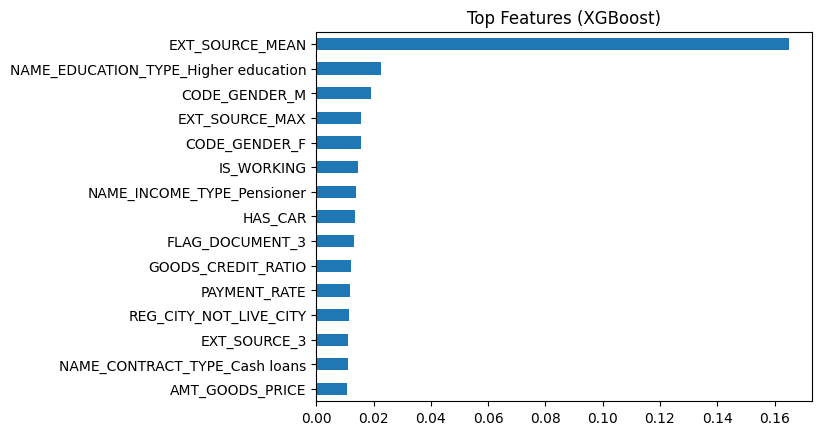

In [ ]:
# Plot the top 15 features
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Features (XGBoost)")
plt.show()

In [ ]:
# Based on the feature importance, we can do a more focused hyperparameter tuning for XGBoost.
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='logloss'
        ))
    ]),
    param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 100}


In [ ]:
# Evaluate the best model on the test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nFinal Model Performance")
print("-" * 30)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Final Model Performance
------------------------------
Accuracy: 0.7039006227338503
Precision: 0.16924690371554135
Recall: 0.6825780463242699
F1 Score: 0.2712393453119373
ROC-AUC: 0.7627272598379323


In [22]:
# Get probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Try multiple thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, recall, precision, f1))

results_df = pd.DataFrame(results, columns=['Threshold', 'Recall', 'Precision', 'F1'])

results_df.sort_values(by='Recall', ascending=False)

,Threshold,Recall,Precision,F1
0,0.10,0.997784,0.082043,0.151619
1,0.15,0.989728,0.085924,0.158121
2,0.20,0.973817,0.092761,0.169388
3,0.25,0.944612,0.101599,0.183465
4,0.30,0.907351,0.112372,0.199978
5,0.35,0.864250,0.124862,0.218199
6,0.40,0.810473,0.138306,0.236289
7,0.45,0.748439,0.152627,0.253548
8,0.50,0.682578,0.169247,0.271239
9,0.55,0.613494,0.189075,0.289063


In [ ]:
# Filter for thresholds that give us at least 70% recall, then pick the one with the best F1 score.
filtered = results_df[results_df['Recall'] >= 0.70]

best_row = filtered.loc[filtered['F1'].idxmax()]

best_row

Threshold       0.430000
Recall          0.721652
Precision       0.107569
F1              0.187229
custom_score    0.476018
Name: 9, dtype: float64

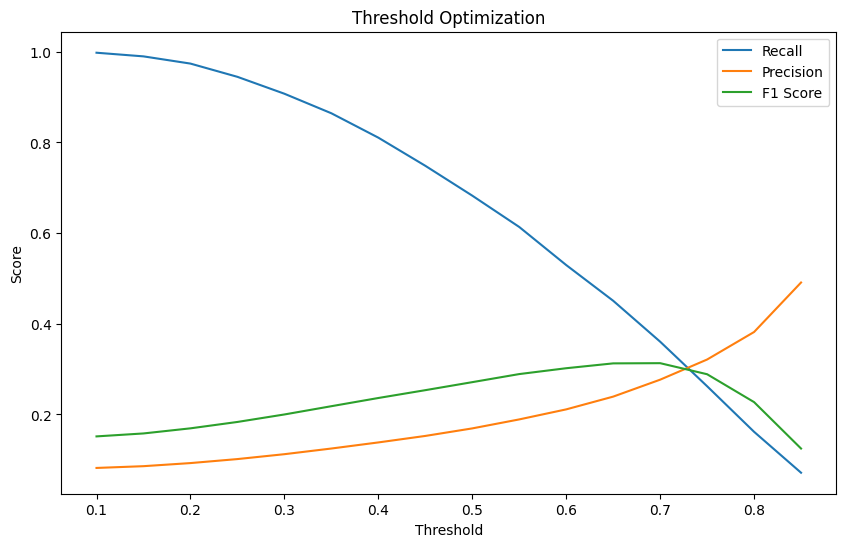

In [ ]:
# Plotting the metrics vs threshold
plt.figure(figsize=(10,6))

plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['F1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()
plt.show()

In [ ]:
# Based on the results, we choose a threshold that gives us a good balance of recall and precision.
best_threshold = 0.45

y_pred_final = (y_prob > best_threshold).astype(int)

print("\nFinal Performance (Optimized Threshold)")
print("-" * 40)
print("Threshold Used:", best_threshold)
print("Recall:", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))


Final Performance (Optimized Threshold)
----------------------------------------
Threshold Used: 0.45
Recall: 0.6725075528700907
Precision: 0.11278500253335585
F1 Score: 0.19317327162279432


In [ ]:
# Save the final model and threshold.
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(best_threshold, "../models/threshold.pkl")

['../models/best_model.pkl']

In [54]:
# ==============================
# MODEL B (FINAL - SCREENING MODEL)
# ==============================

import pandas as pd
import numpy as np

# ==============================
# STEP 1: SELECT APP FEATURES
# ==============================

selected_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CNT_FAM_MEMBERS",
    "CNT_CHILDREN",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

X = df[selected_features].copy()
y = df["TARGET"]

# ==============================
# FEATURE ENGINEERING
# ==============================

X["EMI_INCOME_RATIO"] = X["AMT_ANNUITY"] / (X["AMT_INCOME_TOTAL"] + 1)
X["LOAN_INCOME_RATIO"] = X["AMT_CREDIT"] / (X["AMT_INCOME_TOTAL"] + 1)

X["TOTAL_PAYMENT_RATIO"] = (X["AMT_ANNUITY"] * 12) / (X["AMT_INCOME_TOTAL"] + 1)
X["INCOME_PER_PERSON"] = X["AMT_INCOME_TOTAL"] / (X["CNT_FAM_MEMBERS"] + 1)

X["EMPLOYMENT_AGE_RATIO"] = X["DAYS_EMPLOYED"] / (X["DAYS_BIRTH"] + 1)

# ==============================
# TRAIN-TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# COLUMN TYPES
# ==============================

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# ==============================
# PREPROCESSING
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# ==============================
# MODEL
# ==============================

from xgboost import XGBClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

# ==============================
# TRAIN MODEL
# ==============================

model.fit(X_train, y_train)

# ==============================
# EVALUATION
# ==============================

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nModel B (FINAL - SCREENING)")
print("-" * 50)
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ==============================
# THRESHOLD TUNING (CONTROLLED)
# ==============================

thresholds = np.arange(0.25, 0.65, 0.02)

results = []

for t in thresholds:
    y_pred_t = (y_prob > t).astype(int)
    
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, recall, precision, f1))

results_df = pd.DataFrame(results, columns=['Threshold','Recall','Precision','F1'])

# ==============================
# FINAL THRESHOLD STRATEGY
# ==============================

filtered = results_df[
    (results_df['Recall'] >= 0.55) & 
    (results_df['Precision'] >= 0.10)
]

if not filtered.empty:
    best_row = filtered.loc[filtered['F1'].idxmax()]
    print("Selected from controlled recall zone")
else:
    best_row = results_df.loc[results_df['Recall'].idxmax()]
    print("Fallback to max recall")

print("\nBest Threshold:")
print(best_row)

best_threshold = best_row['Threshold']

# ==============================
# SAVE MODEL
# ==============================

import joblib

joblib.dump(model, "../models/model_no_ext.pkl")
joblib.dump(best_threshold, "../models/threshold_no_ext.pkl")


Model B (FINAL - SCREENING)
--------------------------------------------------
Recall: 0.5413897280966767
Precision: 0.12580146955585716
F1 Score: 0.20416223606258543
ROC-AUC: 0.6487468293477598
Selected from controlled recall zone

Best Threshold:
Threshold    0.490000
Recall       0.565358
Precision    0.122320
F1           0.201125
Name: 12, dtype: float64


['../models/threshold_no_ext.pkl']